# Exploratory Data Analysis (EDA) – Adult Income Dataset

This notebook explores the Adult Income dataset to uncover patterns and potential biases related to gender, income levels, occupation, and working hours. Key goals include:

- Understanding feature distributions
- Investigating gender and income disparities
- Identifying outliers and skewed features
- Preparing insights for bias auditing and fairness metrics

In [13]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
import sys
import os

# Add project root (one level up from notebooks/) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 

In [2]:
df = X.copy()
df['income'] = y 

df.head() #first few rows

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info() # data-types and not-null count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [4]:
df.isnull().sum() # missing values

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Occupation and work-class are not necessary for bias detection but native-country may be

In [15]:
df[df['native-country'].isnull()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32580,40,Private,85019,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,45,NaN,>50K.
32626,41,Private,109912,Bachelors,13,Never-married,Other-service,Not-in-family,White,Female,0,0,40,NaN,<=50K.
32644,44,Self-emp-inc,223881,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,50,NaN,>50K.
32749,34,State-gov,513100,Bachelors,13,Married-spouse-absent,Farming-fishing,Not-in-family,Black,Male,0,0,40,NaN,<=50K.
32814,42,Federal-gov,177937,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,NaN,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48245,46,Private,31411,11th,7,Married-civ-spouse,Other-service,Wife,White,Female,0,0,40,NaN,<=50K.
48272,24,Private,127159,Some-college,10,Never-married,Other-service,Other-relative,White,Female,0,0,24,NaN,<=50K.
48604,24,State-gov,161783,Bachelors,13,Never-married,Transport-moving,Not-in-family,Black,Male,0,0,40,NaN,<=50K.
48651,34,Private,143776,Masters,14,Never-married,Prof-specialty,Not-in-family,Black,Male,0,0,45,NaN,>50K.


Univariate Analysis

In [5]:
df['income'].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Period at the end creates inconsistentcies in result

In [6]:
df['income'] = df['income'].str.replace('.', '', regex=False)
df['income'].value_counts()


income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [9]:
# Age distribution and outlier detection
Q1, Q3 = df['age'].quantile([0.25, 0.75])
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_lower = df[df['age'] < lower_bound]
outliers_higher = df[df['age'] > upper_bound]

print(df['age'].describe())
print(f"\nIQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f} | Outliers: {len(outliers_lower)}")
print(f"Upper bound: {upper_bound:.2f} | Outliers: {len(outliers_higher)}")

# Preview 
display(outliers_lower.head(), outliers_higher.head())



count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

IQR: 20.00
Lower bound: -2.00 | Outliers: 0
Upper bound: 78.00 | Outliers: 216


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
74,79,Private,124744,Some-college,10,Married-civ-spouse,Prof-specialty,Other-relative,White,Male,0,0,20,United-States,<=50K
222,90,Private,51744,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,2206,40,United-States,<=50K
430,80,?,107762,HS-grad,9,Widowed,?,Not-in-family,White,Male,0,0,24,United-States,<=50K
918,81,Self-emp-not-inc,136063,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,30,United-States,<=50K
1040,90,Private,137018,HS-grad,9,Never-married,Other-service,Not-in-family,White,Female,0,0,40,United-States,<=50K


--- Descriptive Statistics for hours-per-week ---
count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

IQR: 5.00
Lower Bound: 32.50 | Outliers: 8286
Upper Bound: 52.50 | Outliers: 5210

Top 10 extreme values:
hours-per-week
99    137
98     14
97      2
96      9
95      2
94      1
92      3
91      3
90     42
89      3
Name: count, dtype: int64


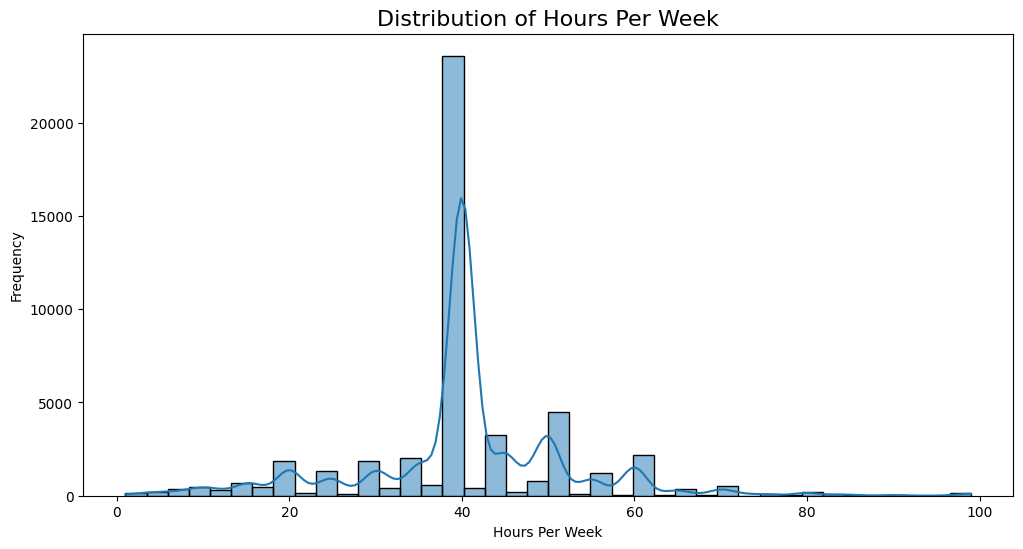

In [10]:
# Hours per week analysis
Q1, Q3 = df['hours-per-week'].quantile([0.25, 0.75])
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_lower = df[df['hours-per-week'] < lower_bound]
outliers_higher = df[df['hours-per-week'] > upper_bound]

print("--- Descriptive Statistics for hours-per-week ---")
print(df['hours-per-week'].describe())
print(f"\nIQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Outliers: {len(outliers_lower)}")
print(f"Upper Bound: {upper_bound:.2f} | Outliers: {len(outliers_higher)}")
print("\nTop 10 extreme values:")
print(df['hours-per-week'].value_counts().sort_index(ascending=False).head(10))

# Plot distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['hours-per-week'], bins=40, kde=True)
plt.title('Distribution of Hours Per Week', fontsize=16)
plt.xlabel('Hours Per Week')
plt.ylabel('Frequency')
plt.show()

Adding a new group (labor_effort_group) in order to categorise data and view extremes with suspicion but not dismiss

labor_effort_group
low        8286
normal    35346
high       5210
Name: count, dtype: int64
                      count       mean       std   min   25%   50%   75%   max
labor_effort_group                                                            
low                  8286.0  21.063601  7.758745   1.0  15.0  20.0  30.0  32.0
normal              35346.0  41.563939  4.019833  33.0  40.0  40.0  42.0  52.0
high                 5210.0  63.466027  9.910780  53.0  57.0  60.0  65.0  99.0


C:\Users\zoyaf\AppData\Local\Temp\ipykernel_20516\370576171.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('labor_effort_group')['hours-per-week'].describe())
C:\Users\zoyaf\AppData\Local\Temp\ipykernel_20516\370576171.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='labor_effort_group', data=df, palette='Set2', order=labels)


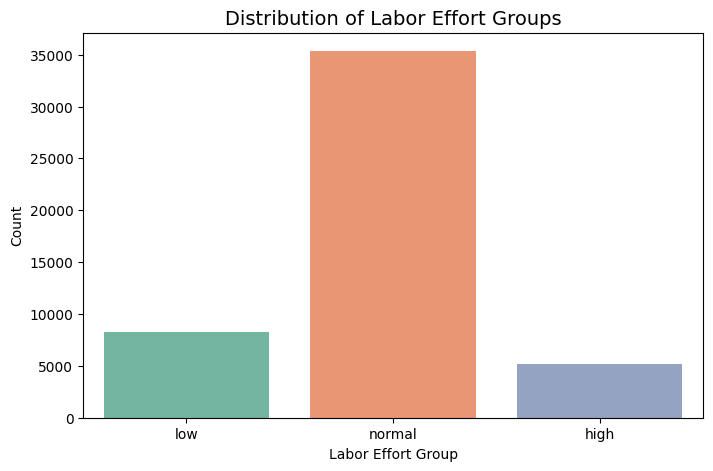

In [11]:
# Define bins and labels
bins = [0, lower_bound, upper_bound, df['hours-per-week'].max()]
labels = ['low', 'normal', 'high']

# Create labor effort group column
df['labor_effort_group'] = pd.cut(df['hours-per-week'], bins=bins, labels=labels, right=True)

# Check distribution
print(df['labor_effort_group'].value_counts().sort_index())

# Summary stats per group
print(df.groupby('labor_effort_group')['hours-per-week'].describe())

# --- Quick Visualization ---
plt.figure(figsize=(8, 5))
sns.countplot(x='labor_effort_group', data=df, palette='Set2', order=labels)
plt.title("Distribution of Labor Effort Groups", fontsize=14)
plt.xlabel("Labor Effort Group")
plt.ylabel("Count")
plt.show()


Women put in the same or even higher labor effort (we’ve seen many in “low” and “normal”), but do not see the same income return.


labor_effort_group       low    normal      high
sex                                             
Female              0.269331  0.680336  0.050333
Male                0.120214  0.745176  0.134609


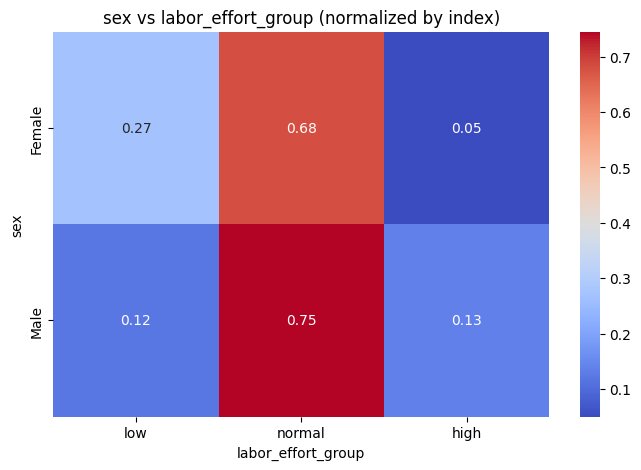

labor_effort_group       low    normal      high
race                                            
Amer-Indian-Eskimo  0.155319  0.748936  0.095745
Asian-Pac-Islander  0.165240  0.739302  0.095458
Black               0.172038  0.774813  0.053148
Other               0.184729  0.741379  0.073892
White               0.169556  0.716920  0.113524


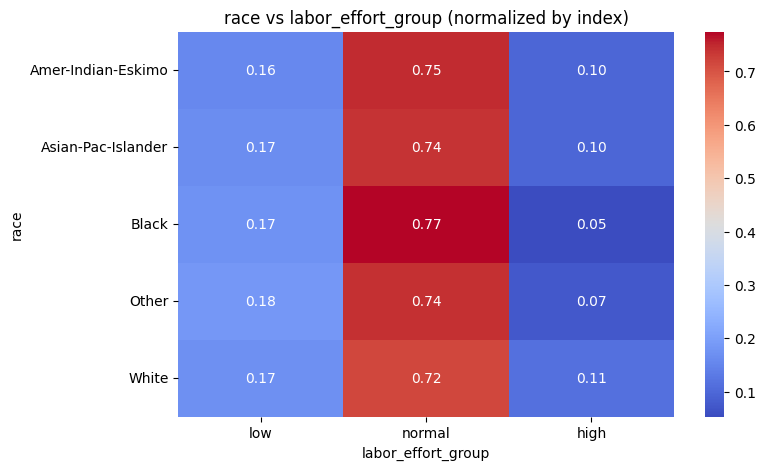

income                 <=50K      >50K
labor_effort_group                    
low                 0.931089  0.068911
normal              0.746336  0.253664
high                0.587332  0.412668


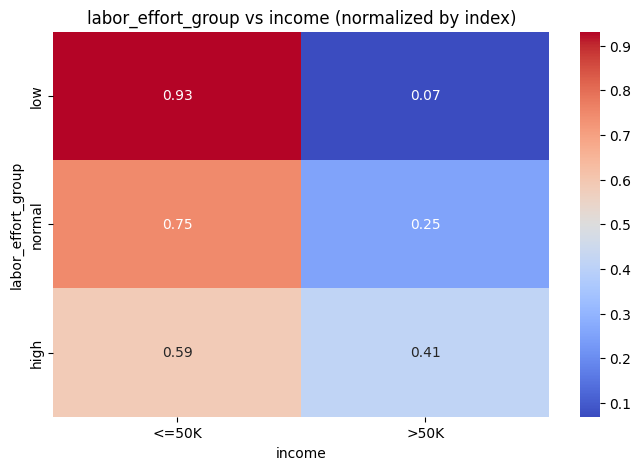

income                        <=50K      >50K
labor_effort_group sex                       
low                Female  0.938317  0.061683
                   Male    0.923057  0.076943
normal             Female  0.880174  0.119826
                   Male    0.685738  0.314262
high               Female  0.779141  0.220859
                   Male    0.551763  0.448237


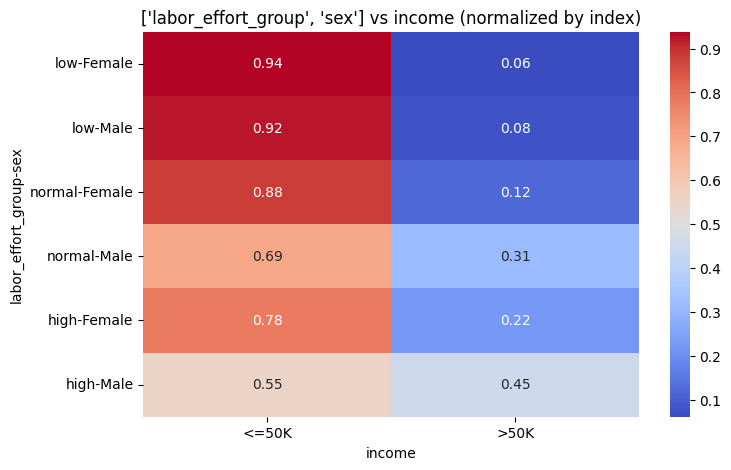

labor_effort_group       low    normal      high
occupation                                      
?                   0.443299  0.508410  0.048291
Adm-clerical        0.179469  0.785421  0.035110
Armed-Forces        0.066667  0.866667  0.066667
Craft-repair        0.061846  0.848495  0.089660
Exec-managerial     0.064410  0.754519  0.181071
Farming-fishing     0.142282  0.569799  0.287919
Handlers-cleaners   0.209942  0.744691  0.045367
Machine-op-inspct   0.069490  0.885837  0.044672
Other-service       0.365834  0.584400  0.049766
Priv-house-serv     0.491736  0.438017  0.070248
Prof-specialty      0.128159  0.733960  0.137881
Protective-serv     0.092574  0.767040  0.140387
Sales               0.213299  0.643532  0.143169
Tech-support        0.134855  0.806362  0.058783
Transport-moving    0.095117  0.713800  0.191083
Unknown             0.454451  0.503106  0.042443


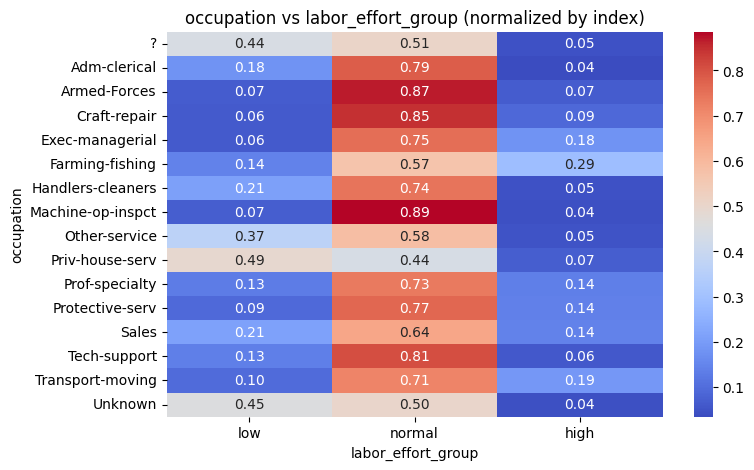

In [ ]:
from utils import plot_helper as plot
plot.plot_crosstab_heatmap('sex', 'labor_effort_group', df)
plot.plot_crosstab_heatmap('race', 'labor_effort_group', df)
plot.plot_crosstab_heatmap('labor_effort_group', 'income', df)
plot.plot_crosstab_heatmap(['labor_effort_group', 'sex'], 'income', df)
plot.plot_crosstab_heatmap('occupation', 'labor_effort_group', df)

In [92]:
pd.set_option('display.max_rows', None)

print(df.groupby(['occupation', 'sex'])['income'].value_counts(normalize=True))

pd.reset_option('display.max_rows')

occupation         sex     income
?                  Female  <=50K     0.938169
                           >50K      0.061831
                   Male    <=50K     0.861277
                           >50K      0.138723
Adm-clerical       Female  <=50K     0.918015
                           >50K      0.081985
                   Male    <=50K     0.750814
                           >50K      0.249186
Armed-Forces       Male    <=50K     0.666667
                           >50K      0.333333
Craft-repair       Female  <=50K     0.897833
                           >50K      0.102167
                   Male    <=50K     0.766799
                           >50K      0.233201
Exec-managerial    Female  <=50K     0.759153
                           >50K      0.240847
                   Male    >50K      0.573306
                           <=50K     0.426694
Farming-fishing    Female  <=50K     0.968421
                           >50K      0.031579
                   Male    <=50K     0.878136


Analysis of patterns per role to confirm above analysis

In [28]:
from utils import eval_helper as ev 
ev.explore_occupation_with_bias(df, 'Exec-managerial')
ev.explore_occupation_with_bias(df, 'Prof-specialty')
ev.explore_occupation_with_bias(df, 'Adm-clerical')
ev.explore_occupation_with_bias(df, 'Machine-op-inspct')
ev.explore_occupation_with_bias(df, 'Craft-repair')



=== Occupation: Exec-managerial ===

Sex distribution:
sex
Male      0.712783
Female    0.287217
Name: proportion, dtype: float64

Sex by labor effort group:
labor_effort_group  sex   
low                 Male      0.558673
                    Female    0.441327
normal              Male      0.695993
                    Female    0.304007
high                Male      0.837568
                    Female    0.162432
Name: proportion, dtype: float64

Income distribution by effort & sex:
labor_effort_group  sex     income
low                 Female  <=50K     0.780347
                            >50K      0.219653
                    Male    <=50K     0.812785
                            >50K      0.187215
normal              Female  <=50K     0.770057
                            >50K      0.229943
                    Male    >50K      0.571026
                            <=50K     0.428974
high                Female  <=50K     0.653631
                            >50K      0.346369
    

c:\Users\zoyaf\bias_auditor\utils\eval_helper.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(occ_df.groupby('labor_effort_group')['sex'].value_counts(normalize=True))
c:\Users\zoyaf\bias_auditor\utils\eval_helper.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(occ_df.groupby(['labor_effort_group', 'sex'])['income'].value_counts(normalize=True))
c:\Users\zoyaf\bias_auditor\utils\eval_helper.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt th

Women are consistently overrepresented in low-effort groups
Underrepresented in high-effort groups
These deviations suggest a gendered division of labor or access, even within the same occupation group.

Both fields are male-dominated (73% and 95% respectively), with women increasingly underrepresented at higher effort levels.
Despite similar effort contributions, women consistently earn less—e.g., in high-effort Craft-Repair, 30% of men earn >50K vs only 15% of women.
This suggests potential structural bias where women's labor is undervalued even when effort is matched.
The pattern may reflect task segregation within roles, promotion access, or broader gender-based valuation discrepancies.


In [29]:
# Define occupation categories
occupation_bins = {
    "blue_collar": ["Craft-repair", "Machine-op-inspct", "Transport-moving", "Handlers-cleaners", "Farming-fishing"],
    "white_collar": ["Exec-managerial", "Prof-specialty", "Tech-support", "Adm-clerical"],
    "pink_collar": ["Other-service", "Priv-house-serv", "Adm-clerical"],  # Overlaps white_collar
    "service_protective": ["Protective-serv", "Armed-Forces"],
    "sales": ["Sales"],
    "unknown": ["Unknown", "?"]
}

occupation_map = {occ: group for group, occupations in occupation_bins.items() for occ in occupations}
df['occupation_group'] = df['occupation'].map(occupation_map)

# Gender-effort-income breakdown per occupation group
summary = df.groupby(['occupation_group', 'labor_effort_group', 'sex'])['income'] \
            .value_counts(normalize=True) \
            .rename("proportion") \
            .reset_index()

print(summary)


   occupation_group labor_effort_group     sex income  proportion
0       blue_collar                low  Female  <=50K    0.968254
1       blue_collar                low  Female   >50K    0.031746
2       blue_collar                low    Male  <=50K    0.966860
3       blue_collar                low    Male   >50K    0.033140
4       blue_collar             normal  Female  <=50K    0.944961
..              ...                ...     ...    ...         ...
67     white_collar             normal    Male  <=50K    0.440421
68     white_collar               high  Female  <=50K    0.678304
69     white_collar               high  Female   >50K    0.321696
70     white_collar               high    Male   >50K    0.657911
71     white_collar               high    Male  <=50K    0.342089

[72 rows x 5 columns]


C:\Users\zoyaf\AppData\Local\Temp\ipykernel_20516\1296777109.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(['occupation_group', 'labor_effort_group', 'sex'])['income'] \


C:\Users\zoyaf\AppData\Local\Temp\ipykernel_20516\2324069867.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['occupation_group', 'labor_effort_group', 'sex'])['income']


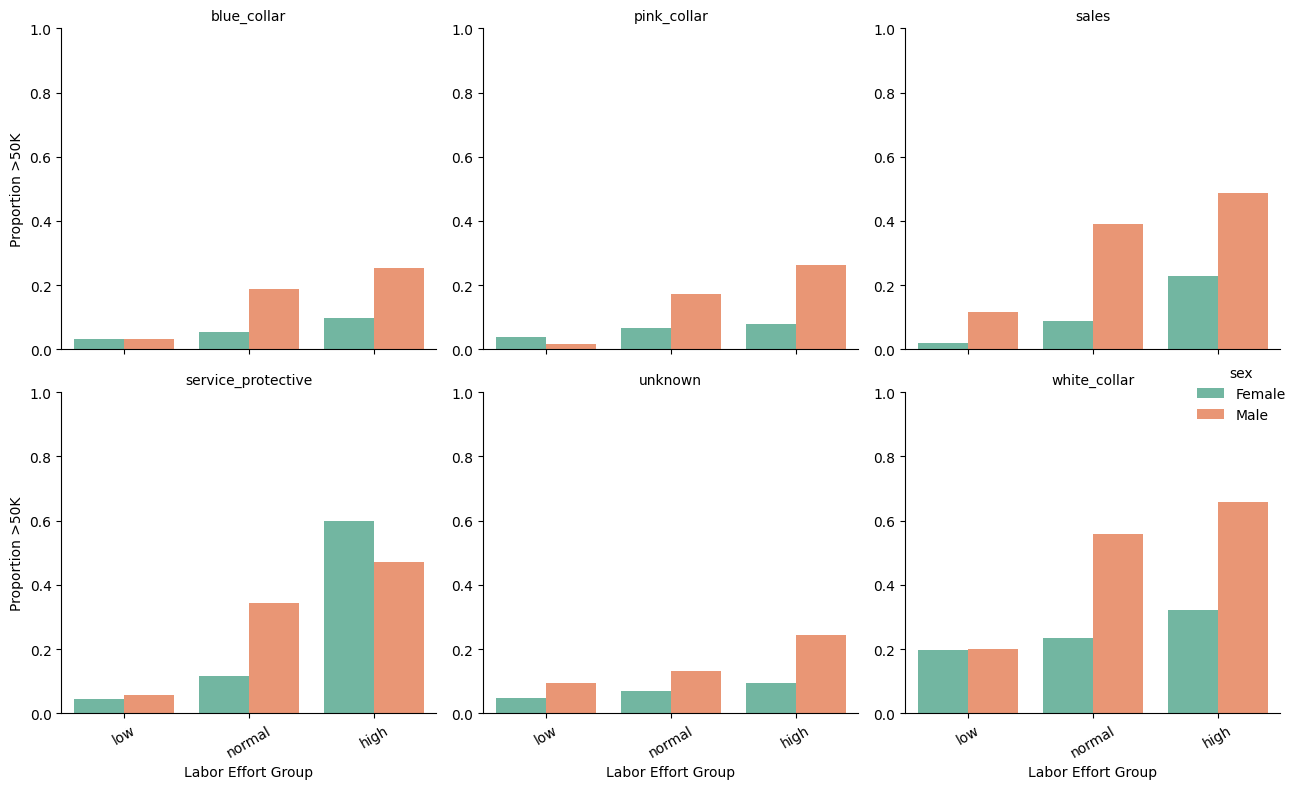

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

summary = (
    df.groupby(['occupation_group', 'labor_effort_group', 'sex'])['income']
      .apply(lambda x: (x == '>50K').mean())  # proportion earning >50K
      .reset_index(name='prop_over_50K')
)

#Plot
g = sns.catplot(
    data=summary,
    x='labor_effort_group',
    y='prop_over_50K',
    hue='sex',
    col='occupation_group',
    kind='bar',
    col_wrap=3,   
    height=4,
    sharey=False,
    palette='Set2'
)

g.set_axis_labels("Labor Effort Group", "Proportion >50K")
g.set_titles("{col_name}")
g.set(ylim=(0, 1))  
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(30)

plt.tight_layout()
plt.show()


**Blue Collar:**

Predominantly male across all effort levels.
Higher effort correlated with a higher chance of >50K income for men.
Women were underrepresented and earned less even at higher effort levels.

**Pink Collar:**

Female-dominated in low and normal effort.
At high effort, male representation increased.
Despite similar or even higher effort, women earned less than men, particularly at high effort—raising questions about potential inequity.

**Sales:**

Mixed gender at low effort; more male-dominated at higher effort.
At high effort, men were far more likely to earn >50K (nearly 49%) than women (23%)—despite similar labor intensity.

**Service Protective:**

Male-dominated.
At high effort, men and women were more evenly compensated compared to other categories, but overall, men still earned more.

**White Collar:**

More balanced gender-wise, though men slightly dominated high-effort segments.
Income disparities persisted: at high effort, both sexes had similar >50K ratios (~65%), but men had a higher representation in high-effort roles.

## Assumptions Behind Bias Score Calculation

1. **Clean Dataset**  
   - All null values have been removed or handled.  
   - Labels such as `sex`, `income`, and `occupation` are consistent.  
   - No known formatting or entry errors remain.

2. **Effort Estimation**  
   - Effort is approximated using `hours-per-week`, binned into *low*, *normal*, and *high*.  
   - Bins are defined per occupation using IQR to minimize distortion by outliers.  
   - Weighted effort scores are calculated using proportions of individuals in each effort bin.  
   - Assumes working more hours generally means more effort, regardless of job type.

3. **Reward Measurement**  
   - Reward is defined as the proportion of individuals earning `>50K` within each gender group.  
   - Assumes `>50K` is a meaningful threshold across all occupations.

4. **Occupation Granularity**  
   - Assumes each occupation category is internally consistent.  
   - Does not account for variation within occupation labels (e.g., senior vs. junior roles).

5. **Sample Size**  
   - No minimum threshold for number of individuals per occupation is enforced.  
   - Small occupations may yield volatile or misleading bias scores.

6. **Gender Distribution and Representation**  
   - Assumes the proportions of men and women reflect real-world hiring patterns.  
   - The model does not account for self-selection bias (e.g., some roles may naturally attract more men/women).

7. **Interpretability of Bias Score**  
   - Bias Score is interpreted as the weighted reward of women relative to combined reward.  
   - If the score is significantly lower than the proportion of women (`p_f`), underrewarding is assumed.  
   - This does not prove discrimination — it only indicates imbalance, which may be due to various structural factors.
